<a href="https://colab.research.google.com/github/Shivam-vachhani/PyTorch-Projects/blob/main/Fully_ANN(Artificial_Neural_Network_)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset ,DataLoader


In [25]:
torch.manual_seed(42)

In [6]:
df = pd.read_csv('fmnist_small.csv')

In [7]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


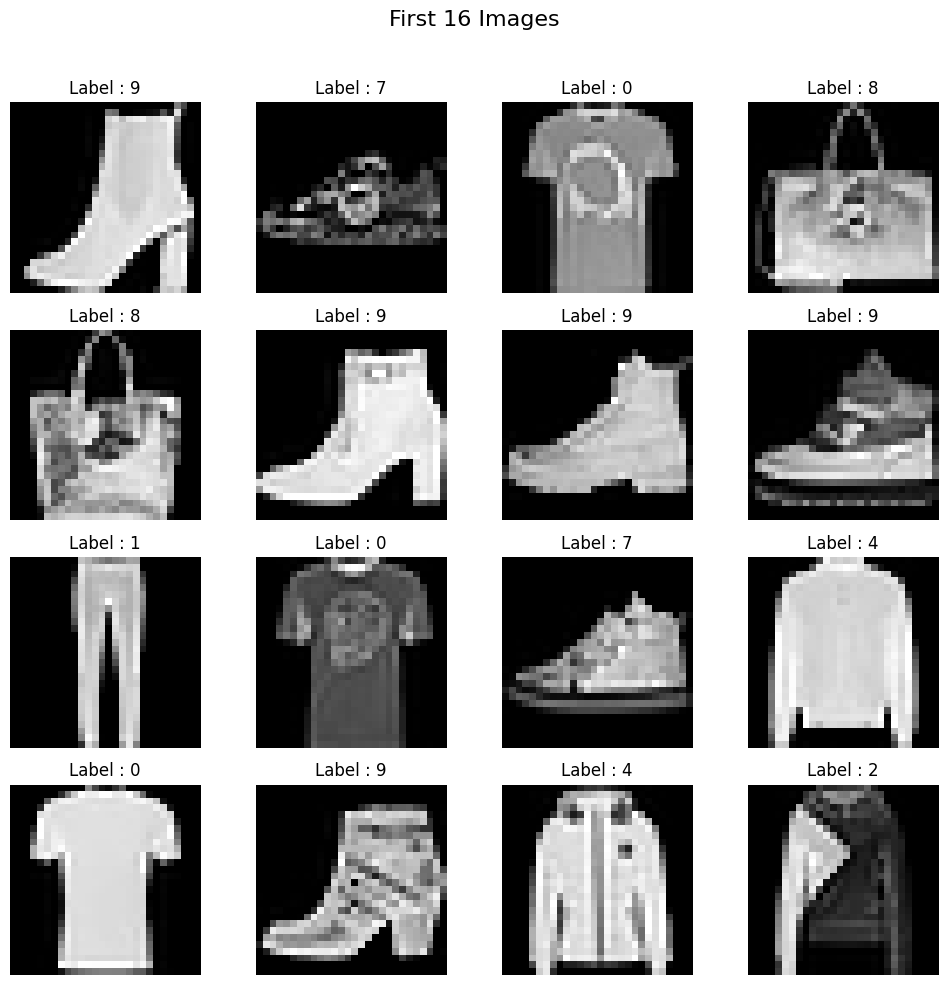

In [8]:
# show imges using matplot lin from dataset
fig ,axes  = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images",fontsize=16)

#loop through axes and datarow at same time
for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28) #getting data into reshape matrix 28*28
  ax.imshow(img, cmap='gray',interpolation='nearest') #show image
  ax.axis('off') # Remove axis to look clean
  ax.set_title(f"Label : {df.iloc[i,0]}")# set label

plt.tight_layout(rect=[0,0,1,0.96]) # make layout
plt.show()

In [9]:
# split data
X = df.iloc[:,1:].values
y = df.iloc[:,0].values


In [10]:
train_X,test_X,train_y,test_y = train_test_split(X,y,test_size=0.2,random_state=42)


In [11]:
#Scaling rgb values between 0 to 1
train_X = train_X/255.0
test_X = test_X/255.0

In [12]:
# Create custom dataset Class
class CustomDataset(Dataset):

  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]



In [13]:
# Create train and test dataset object
train_dataset = CustomDataset(train_X,train_y)
test_dataset = CustomDataset(test_X,test_y)


In [14]:
# train_dataset[0]

In [15]:
train_loder = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loder= DataLoader(test_dataset,batch_size=32,shuffle=True)

In [16]:
# Create NN module Class
class Model(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.module = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10),
    )

  def forward(self,X):
    return self.module(X)


In [17]:
#set epochs and learning rate
epochs = 100
learning_rate = 0.1

In [18]:
# inintialize our model
model = Model(train_X.shape[1])

#Loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [21]:
# Train our model with batches and ephocs
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_label in train_loder:

    #forward pass
    outputs = model(batch_features)

    #loss calulate
    loss = criterion(outputs,batch_label)

    #backward pass
    optimizer.zero_grad()
    loss.backward()

    #update grad
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loder)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 1.3216368440786999
Epoch: 2 , Loss: 0.7793365436792373
Epoch: 3 , Loss: 0.6427524652083715
Epoch: 4 , Loss: 0.5751657336950302
Epoch: 5 , Loss: 0.528180201848348
Epoch: 6 , Loss: 0.49528750121593473
Epoch: 7 , Loss: 0.4602432996034622
Epoch: 8 , Loss: 0.4359459094206492
Epoch: 9 , Loss: 0.41829214423894884
Epoch: 10 , Loss: 0.3984092291692893
Epoch: 11 , Loss: 0.3850264506538709
Epoch: 12 , Loss: 0.3722685620188713
Epoch: 13 , Loss: 0.3477362078428268
Epoch: 14 , Loss: 0.3467242218057315
Epoch: 15 , Loss: 0.3138812760512034
Epoch: 16 , Loss: 0.3126461291313171
Epoch: 17 , Loss: 0.29552092105150224
Epoch: 18 , Loss: 0.2857150869568189
Epoch: 19 , Loss: 0.27084775785605114
Epoch: 20 , Loss: 0.26237100958824155
Epoch: 21 , Loss: 0.25756089876095456
Epoch: 22 , Loss: 0.24232648963729542
Epoch: 23 , Loss: 0.23957946779827277
Epoch: 24 , Loss: 0.2261324493587017
Epoch: 25 , Loss: 0.2233684351791938
Epoch: 26 , Loss: 0.21165308925012746
Epoch: 27 , Loss: 0.21910773759086927
E

In [22]:
# set model to eval mode
model.eval()

Model(
  (module): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [24]:
# defining accuracy of our model on test dataset
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_label in test_loder:
    outputs = model(batch_features)
    _, predicted = torch.max(outputs,1)
    total += batch_label.shape[0]
    correct += (predicted == batch_label).sum().item()

print(correct/total)

0.8325
